# Survival Analysis Modeling

**Research Question:** Which user characteristics and transaction behaviours are associated with a higher risk of churn?

### Why Survival Analysis?

Traditional classification models, such as Logistic Regression, treat churn as a binary outcome (Churned: Yes/No). This approach ignores when a user churned which is an important part of the problem.

It also creates a problem with users who have not churned by the end of the observation period. These censored users are not necessarily retained indefinitely; we simply do not observe their churn event within the available data. Treating them as non-churners or excluding them can therefore distort the analysis.

Survival analysis addresses both issues through a time-to-event framework, using the observed time until churn alongside information about whether the churn event was observed. This allows us to study not only whether users churn, but when churn occurs and how the risk changes over the user lifecycle.

### Methodology

To investigate patterns of retention and factors associated with churn, this notebook uses three methods:

1. **Kaplan–Meier (KM) Estimator:**  
   A non-parametric estimator of the probability of remaining churn-free beyond a given time \(t\). KM curves are used to describe overall retention and compare survival trajectories across groups, such as Auto-Renew vs. Manual users.

2. **Nelson-Aalen Estimators:**   
   To visualize the accumulating risk (cumulative hazard) of churn over time.

3. **Log-Rank Tests:**  
   A hypothesis test used to assess whether the observed survival distributions of two or more groups differ statistically. This provides formal statistical evidence to complement differences observed in the KM curves.

4. **Cox Proportional Hazards (CPH) Regression:**  
   A semi-parametric regression model that examines the association between multiple user characteristics and the hazard of churn, while accounting for time-to-event and censoring. Unlike the KM and log-rank analyses, which examine groups individually, Cox regression allows multiple characteristics to be considered simultaneously.

## Metrics



1. Hazard Ratio (HR) denoted by exp(coef): The relative risk of the event (churn) between two groups at any given moment, from the Cox model.
- HR = 1 means no difference in risk between groups
- HR < 1 means lower risk (protective) e.g. HR = 0.6 means 60% of the reference group's risk
- HR > 1 means higher risk (harmful) e.g. HR = 1.5 means 150% of the reference group's risk
- Note: HR is always relative to a reference category (for categorical variables) or a one-unit increase (for continuous variables).

2. Confidence Interval (CI) on the HR: The range of plausible values for the true HR, given the sample. Not to be confused with the concordance index below.
- CI excludes 1 (e.g. 0.55–0.65) means the effect is statistically distinguishable from "no effect"so we can trust there's a real difference in the direction the HR points
- CI includes 1 (e.g. 0.85–1.20) means "no effect" is still a plausible value within the range so we cannot confidently claim the variable raises or lowers risk, even if the point estimate looks meaningfully off from 1
- A wide interval (regardless of whether it crosses 1) signals imprecision and is worth noting even when significant

3. Concordance Index (C-index): A single number (0.5 to 1.0) measuring how well the whole model ranks who churns first, across all pairs of subjects. 
- 0.5 is no better than random guessing at ranking risk
- 1.0 is perfect discrimination
- About 0.6–0.7 is reasonable and above 0.8 is strong
- Note: A high C-index doesn't mean every individual HR is meaningful, and vice versa because a model can rank well overall while one specific covariate has a weak or unstable effect

4. P-value (for the proportional hazards, PH, test): Tests whether a covariate's effect on risk stays constant over time (proportional hazards), *not* whether the covariate affects risk at all.
- p > 0.05 says no evidence the effect changes over time so we can treat the HR as a reasonable constant summary across the follow-up period
- p < 0.05 is evidence the effect does change over time, as such, the single HR may be misleading as a constant value and it could be an average of a stronger early effect and a weaker later one, or vice versa
Note: At large sample sizes, this test is enabled to flag very small, possibly unimportant deviations so p-value should be read alongside the test statistic's magnitude and the Schoenfeld residual plot, not in isolation

5. KM-transform vs. rank-transform (for the PH test): Two different ways of computing the test statistic with both testing the same underlying question, but with different sensitivity in different situations.
- KM-transform: weights time using the Kaplan-Meier estimate of the survival function
- Rank-transform: uses the rank order of event times rather than the times themselves
- If a variable fails under both transforms, the violation is more clearly definitive, but if it only fails under one, that's a weaker signal worth noting rather than treating as definitive.

In [24]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import median_survival_times
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.statistics import proportional_hazard_test


## 1. Kaplan-Meier Curves

### 1.1 Baseline Survival

*What is the baseline survival probability of a new user over time, irrespective of their specific features?*

In [2]:
# Load the survival table
survival_table = pd.read_csv("data/survival_table_adjusted.csv", parse_dates=["start_date", "endpoint_date"])

Median Survival Time: 195.0 days
95% CI for Median: [195.0 - 196.0] days


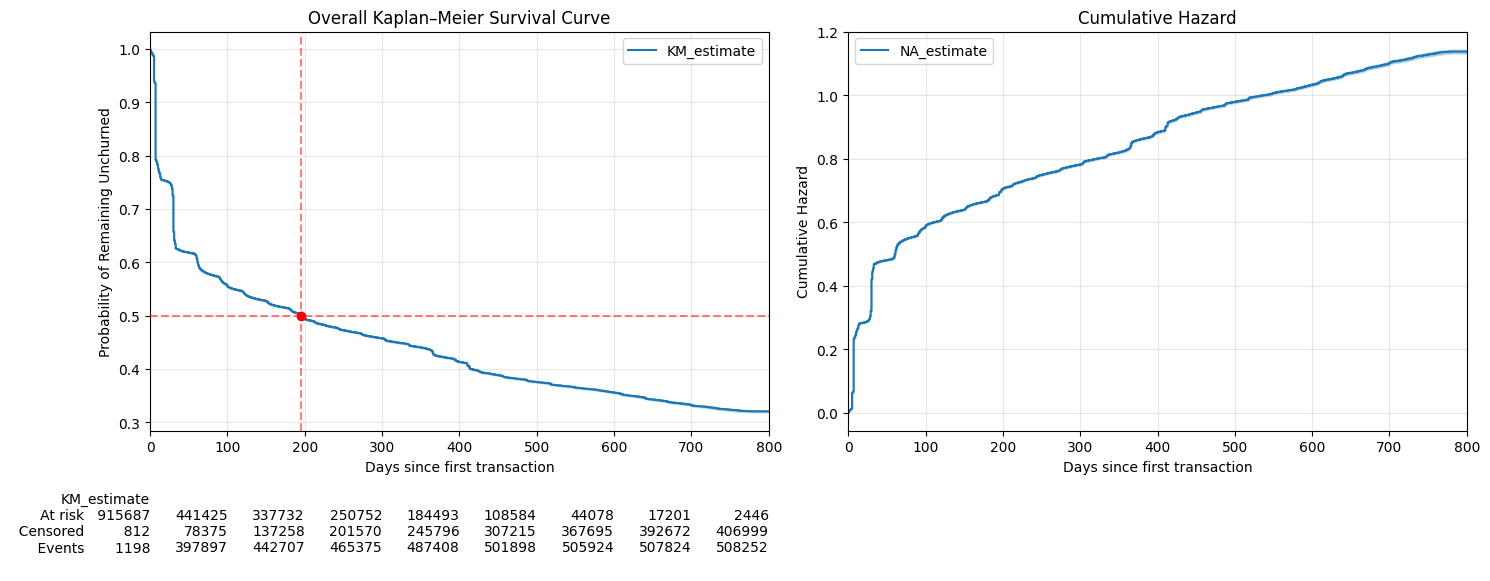

In [3]:
kmf = KaplanMeierFitter()

# Fit KM estimator
kmf.fit(
    durations=survival_table["duration_days"],
    event_observed=survival_table["event"]
)

# Print the Median and its Confidence Interval
median_time = kmf.median_survival_time_
median_ci = median_survival_times(kmf.confidence_interval_)
print(f"Median Survival Time: {median_time} days")
print(f"95% CI for Median: [{median_ci.iloc[0, 0]} - {median_ci.iloc[0, 1]}] days")

# Plot the curve with the Confidence Intervals

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

kmf.plot_survival_function(ci_show=True, ax=axes[0])
axes[0].set_xlim(0, 800)
axes[0].set_title("Overall Kaplan–Meier Survival Curve")
axes[0].set_xlabel("Days since first transaction")
axes[0].set_ylabel("Probability of Remaining Unchurned")
axes[0].grid(alpha=0.3)

from lifelines import NelsonAalenFitter
naf = NelsonAalenFitter()
naf.fit(durations=survival_table["duration_days"], event_observed=survival_table["event"])
naf.plot_cumulative_hazard(ci_show=True, ax=axes[1])
axes[1].set_xlim(0, 800)
axes[1].set_title("Cumulative Hazard")
axes[1].set_xlabel("Days since first transaction")
axes[1].set_ylabel("Cumulative Hazard")
axes[1].grid(alpha=0.3)

# Add At-Risk Counts under the KM curve
from lifelines.plotting import add_at_risk_counts
add_at_risk_counts(kmf, ax=axes[0])

plt.tight_layout()


# Draw a visual dotted line for the median
if median_time != float('inf'): # Only draw it if the curve actually drops below 50%
    plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
    plt.axvline(median_time, color='red', linestyle='--', alpha=0.5)
    plt.plot(median_time, 0.5, 'ro')


- The Kaplan–Meier curve shows a pronounced decline in survival during the early stages of the observation period, with survival probability falling from 1.0 to approximately 0.62 within the first 30 days. The corresponding increase in the Nelson–Aalen cumulative hazard is also steep during this early period, indicating that a large proportion of observed churn occurs near the beginning of the subscriber lifecycle.

- The estimated median survival time is 195 days (95% CI: 195–196 days), meaning that approximately half of the observed cohort experiences churn by this point.

- After approximately 200 days, the survival curve continues to decline but at a less pronounced rate. This suggests that the risk of experiencing the first observed churn event is concentrated earlier in the subscriber lifecycle, while users who remain under observation for longer periods tend to persist for much longer.

- By approximately 800 days, the estimated survival probability remains above 30%. Thus, although the cohort experiences substantial early churn, a meaningful proportion remains churn-free throughout the later part of the observation period.

### 1.2 Survival by Feature



#### 1.2.1 Auto-Renewal

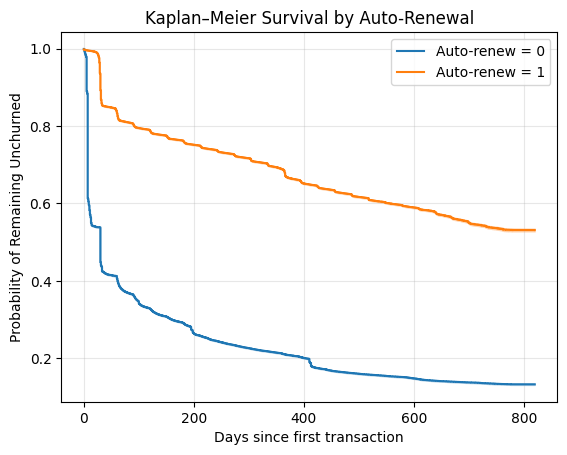

In [4]:
kmf_auto = KaplanMeierFitter()

for value in [0, 1]:
    mask = survival_table["is_auto_renew"] == value
    
    kmf_auto.fit(
        survival_table.loc[mask, "duration_days"],
        event_observed=survival_table.loc[mask, "event"],
        label=f"Auto-renew = {value}"
    )
    
    kmf_auto.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival by Auto-Renewal")
plt.xlabel("Days since first transaction")
plt.ylabel("Probability of Remaining Unchurned")
plt.grid(alpha=0.3)
plt.show()

The curves separate immediately at the beginning and survival among users without auto-renewal falls to approximately 0.55 within the first few days. In comparison, the auto-renewing users experiences a smaller initial decline. The gap between the groups remains throughout the follow-up period and does not meet later. By approximately 800 days, the estimated survival probability remains above 0.50 for the auto-renewing group, compared with approximately 0.15 for the non-auto-renewing group.

In [5]:
# Statistically test for differences in survival curves across groups

group_0 = survival_table[survival_table["is_auto_renew"] == 0]
group_1 = survival_table[survival_table["is_auto_renew"] == 1]

results = logrank_test(
    group_0["duration_days"],
    group_1["duration_days"],
    event_observed_A=group_0["event"],
    event_observed_B=group_1["event"]
)

results.print_summary()

With a p-value of <0.005, the difference in survival distributions between users with and without auto-renewal is statistically significant, rejecting the null hypothesis.

#### 1.2.2 Payment ID

Payment methods with fewer than 500 users are excluded from the KM plot to ensure stable estimates.

In [6]:
payment_counts = survival_table["payment_method_id"].value_counts()

# Filter out methods with >500 users
payment_methods_eda = payment_counts[payment_counts >= 500].index

km_payment = survival_table[
    survival_table["payment_method_id"].isin(payment_methods_eda)
].copy()

km_payment["payment_method_id"].nunique()

24

In [7]:
# Verify the volume of churned vs censored status
pd.crosstab(
    km_payment["payment_method_id"],
    km_payment["event"]
)

event,0,1
payment_method_id,,
12,763,335
13,842,299
16,380,225
17,1618,344
18,365,201
20,4291,4715
22,3074,1541
23,608,289
25,107,980


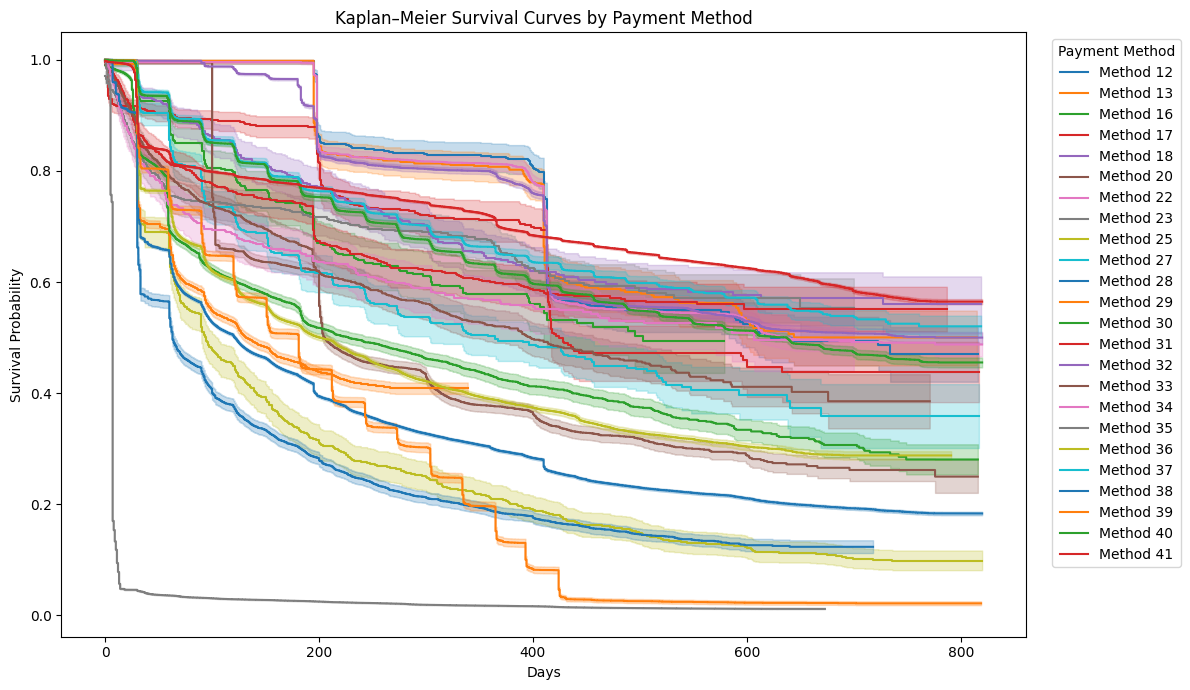

In [8]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 7))

for payment_method in sorted(km_payment["payment_method_id"].unique()):
    mask = km_payment["payment_method_id"] == payment_method
    
    kmf.fit(
        durations=km_payment.loc[mask, "duration_days"],
        event_observed=km_payment.loc[mask, "event"],
        label=f"Method {payment_method}"
    )
    
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival Curves by Payment Method")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.legend(title="Payment Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The crossing of the curves suggests that survial varies depending on the payment method used. One payment method (the lowest grey line) crashes almost immediately from 1.0 down to roughly a 0.05 survival probability within the first few days, suggesting a payment channel that is practically synonymous with instant churn. Several other payment methods exhibit a pattern where survival remains almost perfectly flat at 1.0 for longer periods, going between day 200 and day 400, before dropping. By the end of the window, the survival outcomes based on payment method are significantly different. The cluster of payment methods at the top maintains a survival probability between 0.4 and 0.6, while the lowest-performing methods drop to below 0.2. The crossing of the survival curves suggests that the hazard rate for payment methods is not constant over time (a violation of proportional hazards).

In [9]:
result = multivariate_logrank_test(
    event_durations=km_payment["duration_days"],
    groups=km_payment["payment_method_id"],
    event_observed=km_payment["event"]
)

result.print_summary()

The log-rank test rejects the null hypothesis of equal survival across payment methods (p < 0.005), confirming that the payment method a subscriber uses is a statistically significant factor in churn.

#### 1.2.3 Payment Plan Duration

In [10]:
km_plan = survival_table.copy()

# Bin plan duration
km_plan["plan_days_group"] = np.select(
    [
        km_plan["payment_plan_days"] == 0,
        km_plan["payment_plan_days"].between(1, 7),
        km_plan["payment_plan_days"].between(8, 29),
        km_plan["payment_plan_days"] == 30,
        km_plan["payment_plan_days"] > 30
    ],
    [
        "0 days",
        "1–7 days",
        "8–29 days",
        "30 days",
        ">30 days"
    ],
    default="Other"
)

km_plan["plan_days_group"].value_counts()

plan_days_group
30 days      590791
1–7 days     226062
>30 days      80084
0 days        10508
8–29 days     10252
Name: count, dtype: int64

In [11]:
# Verify volume
pd.crosstab(
    km_plan["plan_days_group"],
    km_plan["event"]
)

event,0,1
plan_days_group,,
0 days,2864,7644
1–7 days,5466,220596
30 days,349970,240821
8–29 days,401,9851
>30 days,50744,29340


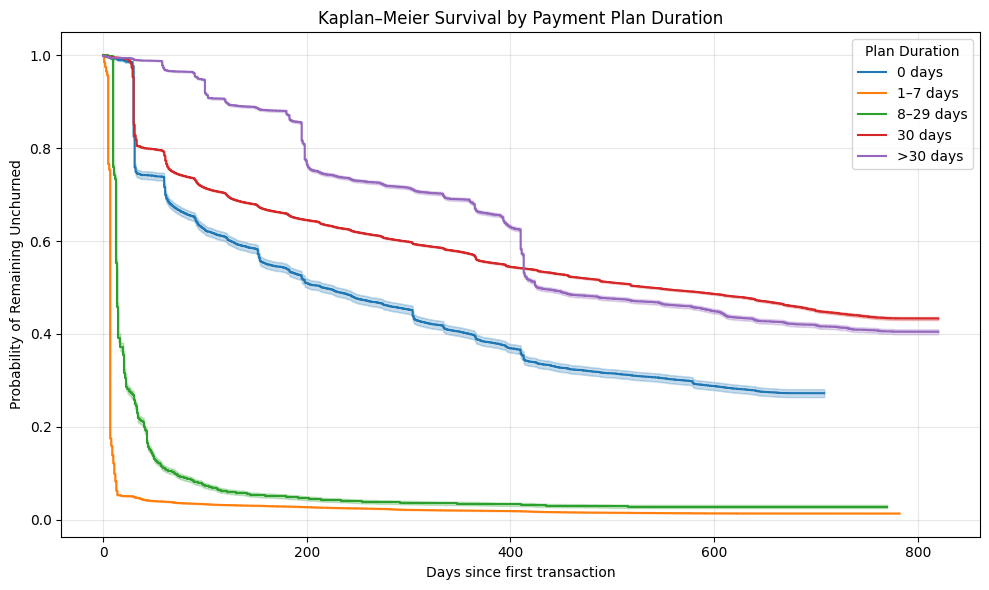

In [12]:
plt.figure(figsize=(10, 6))

for group in ["0 days", "1–7 days", "8–29 days", "30 days", ">30 days"]:
    mask = km_plan["plan_days_group"] == group
    
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=km_plan.loc[mask, "duration_days"],
        event_observed=km_plan.loc[mask, "event"],
        label=group
    )
    
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival by Payment Plan Duration")
plt.xlabel("Days since first transaction")
plt.ylabel("Probability of Remaining Unchurned")
plt.legend(title="Plan Duration")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- The survival curves for the "1-7 days" and "8-29 days" plans collapse almost instantly, dropping to almost zero survival probabilities within the first 30 days so users entering through these duration buckets almost never survive past their initial cycle. Interestingly, the "0 days" plan does not exhibit immediate churn. Instead, it maintains a relatively flat survival rate until it drops at about the 30-day mark, and settles around a 0.25 long-term survival probability. 
- The ">30 days" cohort maintains high survival for extended stretches, only to show significant step downs at around the 200-day and 400-day marks. Even though the ">30 days" plan outperforms the  "30 days" plan for the first year, both curves intersect, with the ">30 days" cohort falling slightly below the "30 days" cohort. For the rest of the 800-day window, the curves are almost identical, settling around 0.4, indicating that over a multi-year period, the advantage of long-term upfront commitments eventually normalises against the steady drop of monthly renewals. The crossing of the survival curves suggests that the hazard rate for plan duration is not constant over time (a violation of proportional hazards).

In [13]:
result_plan = multivariate_logrank_test(
    event_durations=km_plan["duration_days"],
    groups=km_plan["plan_days_group"],
    event_observed=km_plan["event"]
)

result_plan.print_summary()

## Cox Proportional Hazards (PH) Regression

*When we control for all overlapping features simultaneously, which user behaviours are the true drivers of churn?*

Kaplan-Meier curves are great for visualising single variables, but they cannot account for the overlapping nature of user behaviour (e.g., the fact that users on Auto-Renew might also prefer a specific Payment Method). The Cox Proportional Hazards model is a multivariable regression that allows us to isolate the true, independent impact of a specific feature on churn risk while holding all other variables constant.

### 2.1 Unadjusted Models

Before building the multivariable models, we first fit individual Cox models to establish the independent hazard ratio for each covariate.


In [14]:
# Unadjusted Auto-Renew
cox_data = survival_table.copy()

cph_auto = CoxPHFitter(penalizer=0.01)
cph_auto.fit(cox_data[['duration_days', 'event', 'is_auto_renew']], duration_col='duration_days', event_col='event')
print("Unadjusted: Auto-Renew")
cph_auto.print_summary()

Unadjusted: Auto-Renew


<lifelines.CoxPHFitter: fitted with 917697 total observations, 409445 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 917697
number of events observed = 508252
   partial log-likelihood = -6598210.48
         time fit was run = 2026-09-23 21:22:11 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
is_auto_renew -1.47      0.23      0.00           -1.48           -1.46                0.23                0.23

               cmp to       z      p  -log2(p)
covariate                                     
is_auto_renew    0.00 -466.74 <0.005       inf
---
Concordance = 0.70
Partial AIC = 13196422.97
log-likelihood ratio test = 250122.33 on 1 df
-log2(p) of ll-ratio test = inf

The hazard ratio (HR) indicated by exp(coef) is 0.23. This means users with auto-renewal enabled experience a 77% reduction in their baseline risk of churning at any given time. The Concordance index of 0.7 means just knowing this one single feature allows the model to correctly predict which of two randomly selected users will churn first 70% of the time. And finally, the 95% confidence interval sitting at exactly 0.23 confirms this 77% risk reduction is definitive and constant rather than a statistical fluctuation.

In [15]:
# Unadjusted Plan Duration
conditions = [
    cox_data["payment_plan_days"] == 0,
    cox_data["payment_plan_days"].between(1, 7),
    cox_data["payment_plan_days"].between(8, 29),
    cox_data["payment_plan_days"] == 30,
    cox_data["payment_plan_days"] > 30
]
labels = ["0 days", "1–7 days", "8–29 days", "30 days", ">30 days"]
cox_data_unadj = cox_data.copy()
cox_data_unadj["plan_group"] = np.select(conditions, labels, default="Other")

# One-hot encode Plan Duration
plan_dummies = pd.get_dummies(cox_data_unadj["plan_group"], prefix="plan", drop_first=False)
if "plan_30 days" in plan_dummies.columns:
    plan_dummies.drop(columns=["plan_30 days"], inplace=True) # 30 days as baseline

df_plan = pd.concat([cox_data_unadj[['duration_days', 'event']], plan_dummies], axis=1)
cph_plan = CoxPHFitter(penalizer=0.01)
cph_plan.fit(df_plan, duration_col='duration_days', event_col='event')
print("\nUnadjusted: Plan Duration (Ref: 30 days)")
cph_plan.print_summary()


Unadjusted: Plan Duration (Ref: 30 days)


<lifelines.CoxPHFitter: fitted with 917697 total observations, 409445 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 917697
number of events observed = 508252
   partial log-likelihood = -6402358.61
         time fit was run = 2026-09-23 21:27:36 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
plan_0 days     0.44      1.55      0.01            0.42            0.46                1.52                1.59
plan_1–7 days   2.91     18.44      0.00            2.91            2.92               18.32               18.57
plan_8–29 days  1.85      6.35      0.01            1.83            1.87                6.22                6.48
plan_>30 days  -0.27      0.76      0.01           -0.28           -0.26                0.76                0.77

                cmp to      z      p  -log2(p)
covariate                                     
plan_0 days       0.00  37.87 <0.005       inf
plan_1–7 days     0.00 853.16 <0.005       inf
plan_8–29 days    0.00 177.82 <0.005       inf
plan_>30 days     0.00 -44.25 <0.005       inf
---
Concordance = 0.77
Partial AIC = 12804725.22
log-likelihood ratio test = 641826.08 on 4 df
-log2(p) of ll-ratio test = inf

- Compared to the 30-day baseline plan, users on 1–7 day plans face a 18.4 times higher risk of churning at any given moment (HR = 18.44, 95% CI: 18.32–18.57).
- The 8–29 day plans carry over 6 times the churn risk of a 30-day plan (HR = 6.35, 95% CI: 6.22–6.48), while the "0 days" tier shows a 55% higher risk (HR = 1.55, 95% CI: 1.52–1.59).
- In contrast, users on >30 days plans experience a 24% lower churn risk (HR = 0.76, 95% CI: 0.76–0.77) compared to the baseline monthly cohort.

In [16]:
# Unadjusted Payment Method
# Group Payment Methods
payment_method_counts = cox_data_unadj["payment_method_id"].value_counts()
popular_methods = payment_method_counts[payment_method_counts > 10000].index
cox_data_unadj["payment_method_grouped"] = cox_data_unadj["payment_method_id"].apply(
    lambda x: str(x) if x in popular_methods else "Other"
)

# One-hot encode Payment Methods
method_dummies = pd.get_dummies(cox_data_unadj["payment_method_grouped"], prefix="method", drop_first=False)
baseline_method = str(cox_data_unadj["payment_method_grouped"].mode()[0])
baseline_col = f"method_{baseline_method}"
if baseline_col in method_dummies.columns:
    method_dummies.drop(columns=[baseline_col], inplace=True)

df_method = pd.concat([cox_data_unadj[['duration_days', 'event']], method_dummies], axis=1)
cph_method = CoxPHFitter(penalizer=0.01)
cph_method.fit(df_method, duration_col='duration_days', event_col='event')
print(f"\nUnadjusted: Payment Method (Ref: {baseline_method})")
cph_method.print_summary()


Unadjusted: Payment Method (Ref: 41)


<lifelines.CoxPHFitter: fitted with 917697 total observations, 409445 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 917697
number of events observed = 508252
   partial log-likelihood = -6385233.38
         time fit was run = 2026-09-23 21:35:57 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
method_29     0.85      2.35      0.01            0.83            0.88                2.30                2.40
method_30     0.69      1.99      0.01            0.66            0.72                1.94                2.05
method_32    -0.25      0.78      0.01           -0.28           -0.23                0.76                0.79
method_35     3.34     28.30      0.00            3.33            3.35               28.07               28.53
method_36     0.75      2.11      0.01            0.73            0.76                2.08                2.14
method_38     1.05      2.87      0.00            1.05            1.06                2.85                2.90
method_39     1.16      3.19      0.01            1.14            1.18                3.13                3.26
method_40     0.15      1.16      0.01            0.13            0.17                1.14                1.19
method_Other  0.47      1.59      0.01            0.45            0.48                1.57                1.62

              cmp to      z      p  -log2(p)
covariate                                   
method_29       0.00  73.69 <0.005       inf
method_30       0.00  49.93 <0.005       inf
method_32       0.00 -21.22 <0.005    329.67
method_35       0.00 812.58 <0.005       inf
method_36       0.00 108.04 <0.005       inf
method_38       0.00 248.98 <0.005       inf
method_39       0.00 111.61 <0.005       inf
method_40       0.00  14.41 <0.005    153.94
method_Other    0.00  60.09 <0.005       inf
---
Concordance = 0.80
Partial AIC = 12770484.77
log-likelihood ratio test = 676076.53 on 9 df
-log2(p) of ll-ratio test = inf

- Method 35 has a 28.3 times higher risk of churning (HR = 28.30, 95% CI:28.07–28.53) compared to the baseline payment method 41. While not as bad as Method 35, other channels severely degrade user retention.
- Methods 39 and 38 are also as major churn multipliers, increasing the baseline risk by 3.19 times (CI: 3.13–3.26) and 2.87 (CI: 2.85–2.90) times, respectively. 
- In contrast, Method 32 protects from churn through a 22% reduction in baseline churn risk (HR = 0.78, CI: 0.76–0.79).

### 2.2 The Fully Adjusted Multivariable Model: Model 1

We know Auto-Renewal, Plan Duration, and Payment Method are all significant standalone predictors. But what happens when we run them simultaneously? Does the 77% risk reduction of Auto-Renewal hold up when we control for the fact that certain Payment Methods block auto-renewal from happening? To find out, we combine all covariates into a single, fully adjusted Cox model. By testing these features simultaneously, we can measure the independent impact of each feature on churn risk while controlling for overlapping user behaviours.

Model 1: Fully Adjusted


<lifelines.CoxPHFitter: fitted with 917697 total observations, 409445 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 917697
number of events observed = 508252
   partial log-likelihood = -6358876.28
         time fit was run = 2026-09-23 21:37:02 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
is_auto_renew  -1.00      0.37      0.01           -1.02           -0.98                0.36                0.38
plan_0 days     0.17      1.18      0.01            0.15            0.19                1.16                1.21
plan_1–7 days   1.46      4.33      0.01            1.44            1.49                4.24                4.42
plan_8–29 days  1.23      3.40      0.01            1.20            1.25                3.33                3.48
plan_>30 days  -0.69      0.50      0.01           -0.71           -0.68                0.49                0.51
method_29       0.05      1.05      0.01            0.02            0.08                1.03                1.08
method_30       0.82      2.27      0.01            0.79            0.84                2.20                2.33
method_32      -0.53      0.59      0.02           -0.56           -0.50                0.57                0.61
method_35       1.00      2.72      0.01            0.97            1.02                2.65                2.78
method_36      -0.02      0.98      0.01           -0.04           -0.00                0.96                1.00
method_38       0.12      1.13      0.01            0.10            0.14                1.10                1.15
method_39       1.35      3.84      0.01            1.33            1.37                3.76                3.92
method_40       0.37      1.45      0.01            0.35            0.39                1.42                1.48
method_Other    0.14      1.15      0.01            0.12            0.16                1.13                1.18

                cmp to       z      p  -log2(p)
covariate                                      
is_auto_renew     0.00 -106.71 <0.005       inf
plan_0 days       0.00   14.46 <0.005    155.01
plan_1–7 days     0.00  139.99 <0.005       inf
plan_8–29 days    0.00  114.62 <0.005       inf
plan_>30 days     0.00  -92.12 <0.005       inf
method_29         0.00    3.72 <0.005     12.27
method_30         0.00   59.06 <0.005       inf
method_32         0.00  -34.01 <0.005    839.74
method_35         0.00   78.49 <0.005       inf
method_36         0.00   -2.08   0.04      4.72
method_38         0.00   12.20 <0.005    111.34
method_39         0.00  128.11 <0.005       inf
method_40         0.00   34.52 <0.005    864.79
method_Other      0.00   13.87 <0.005    142.81
---
Concordance = 0.81
Partial AIC = 12717780.55
log-likelihood ratio test = 728790.75 on 14 df
-log2(p) of ll-ratio test = inf

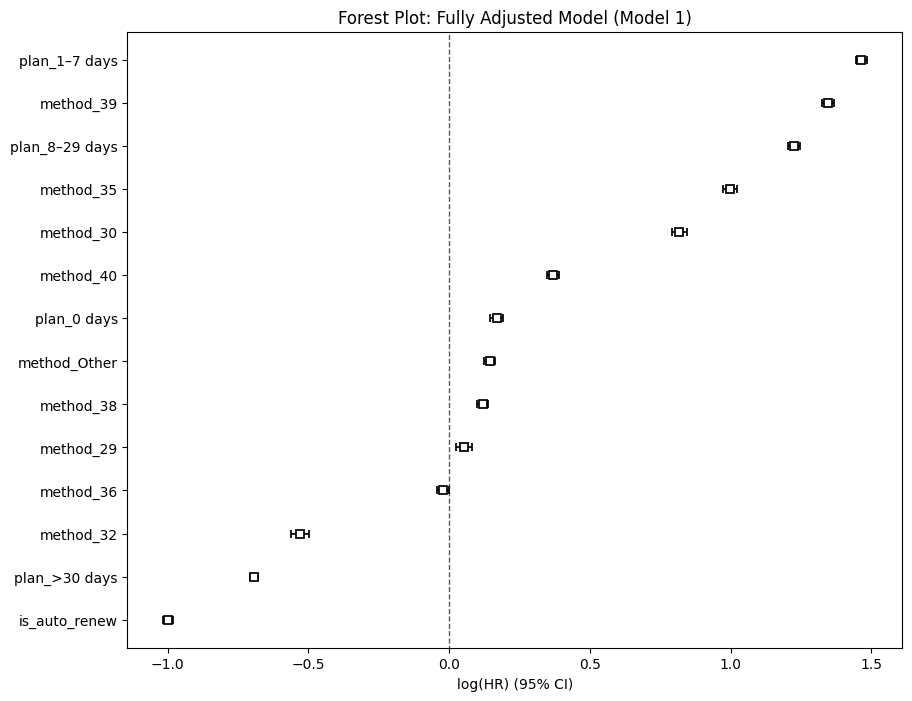

In [17]:
# Combine all features into a fully adjusted model
df_adjusted = pd.concat([
    cox_data_unadj[['duration_days', 'event', 'is_auto_renew']], 
    plan_dummies, 
    method_dummies
], axis=1)

# Fit Model
cph_adjusted = CoxPHFitter(penalizer=0.01)
cph_adjusted.fit(df_adjusted, duration_col='duration_days', event_col='event')

print("Model 1: Fully Adjusted")
cph_adjusted.print_summary()

# Forest Plot ---
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
cph_adjusted.plot()
plt.title('Forest Plot: Fully Adjusted Model (Model 1)')
plt.show()

When we put all these variables to compete in the same model, the results are different. The Concordance index goes up to 0.81, meaning this combined model's predictive power is  accurate. But the HR show some significant changes:

- In the unadjusted model, Payment Method 35 looked like a guaranteed churn funnel with a 28.3x churn multiplier. In the fully adjusted model, that risk falls to 2.72x (CI: 2.65–2.78). This suggests that Method 35  was affected by the risk of manual renewals and short-term plans. Method 32 sees a 41% risk reduction (HR = 0.59, CI: 0.57–0.61), becoming more protective. Method 39, with a 3.84x ((3.76–3.92)) churn risk increased sligtly compared to the unadjusted model and has the highest risk among payment methods in the entire model. Notable, Method 36 seemed to change direction completely to have a protective effect against churn (HR = 0.98).However, with a CI of 0.96–1.00 this is now a non-significant result.

- The 18.4x risk multiplier we saw for plan_1–7 days drops significantly to 4.33x (CI: 4.24–4.42), plan_8-29 days along with plan_0 days also see a reduction compared to the unadjusted model, although they remain significant churn multipliers compared to the baseline 30-day plan. In contrast, plan_>30 days sees a 50% risk reduction (HR = 0.50, CI: 0.49–0.51), higher than the unadjusted value.

- Auto-renewal still maintains good results with a 63% reduction in baseline churn risk (HR = 0.37, CI: 0.36–0.38). It doesn't matter what plan the user is on or how they pay, if they are automatically billed, likelihood of surviving increases significantly.

### Proportional Hazards Assumptions Check: Model 1
A main assumption of a Cox model is that the hazard ratio stays constant. If a feature doubles risk on Day 1, it should double risk on Day 100, and so we have to test for this. However, with nearly a million rows, standard statistical tests become hyper-sensitive and flag tiny variances as failures. To get a holistic read on our assumptions, we'll run the test across three distinct sample sizes (5k, 10k, and 15k).

#### n = 5000


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'plan_1–7 days' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['plan_1–7 days', ...]` in
the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


2. Variable 'plan_8–29 days' failed the non-proportional test: p-value is 0.0318.

   Advice: with so few unique values (only 2), you can include `strata=['plan_8–29 days', ...]` in
the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


3. Variable 'plan_>30 days' failed the non-proportional test: p-value is 0.0070.

   Advice: with so few unique values (only 2), you can include `strata=['plan_>30 days', ...]` in
the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrap

[[<Axes: xlabel='rank-transformed time\n(p=0.8151)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8275)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7065)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7672)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2809)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0318)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0259)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0070)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1851)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1340)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4030)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5500)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0914)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0588)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9340)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6293)'>],
 [<Axes: xlabel='rank-transformed tim

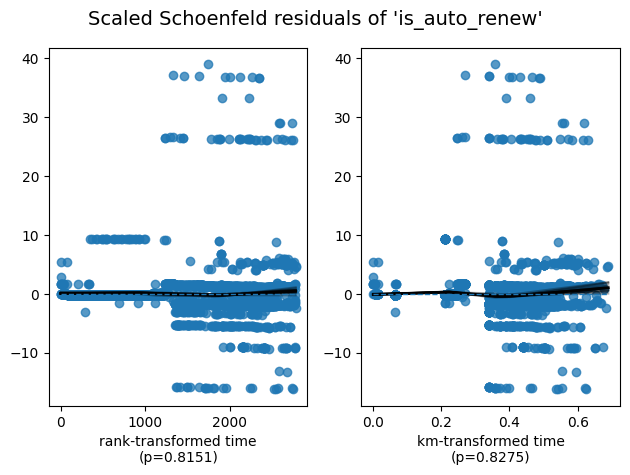

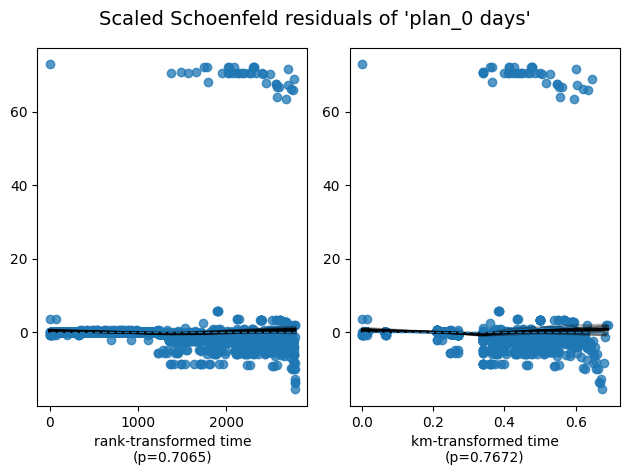

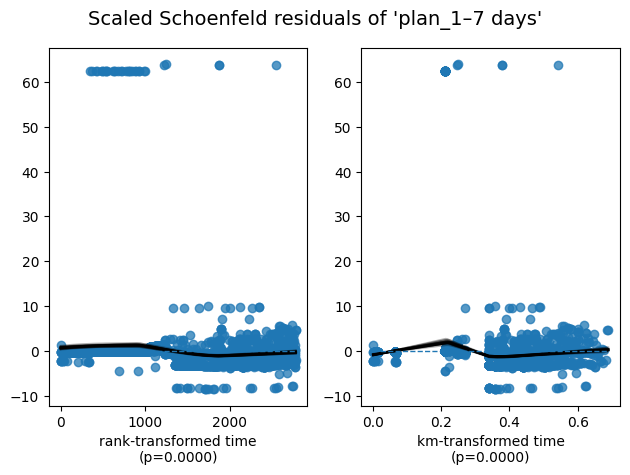

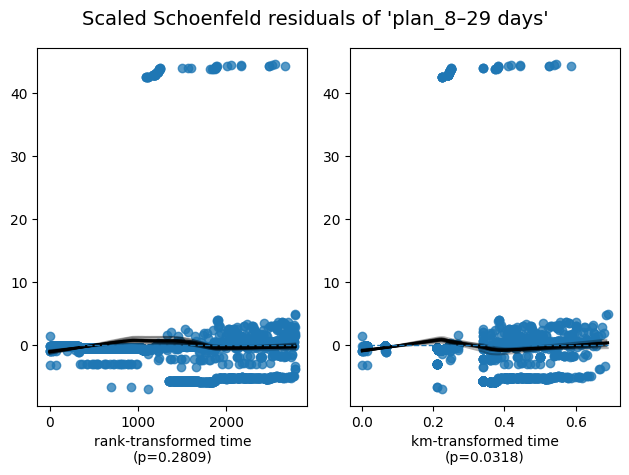

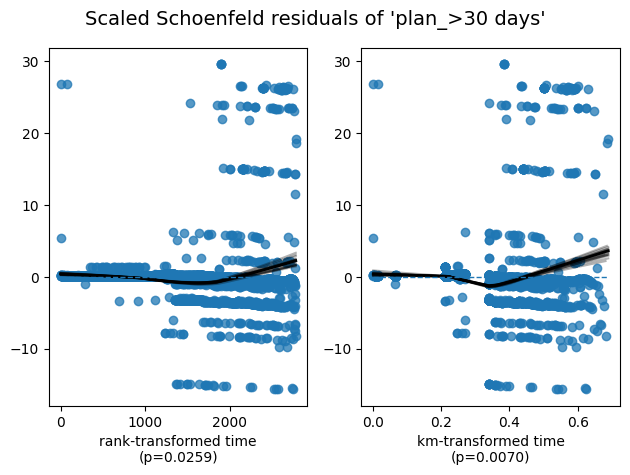

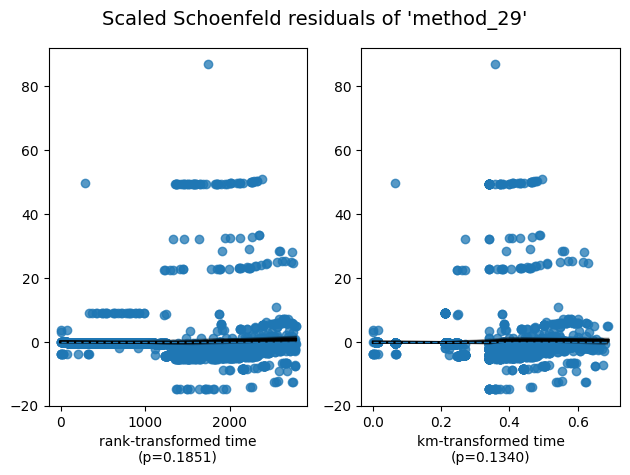

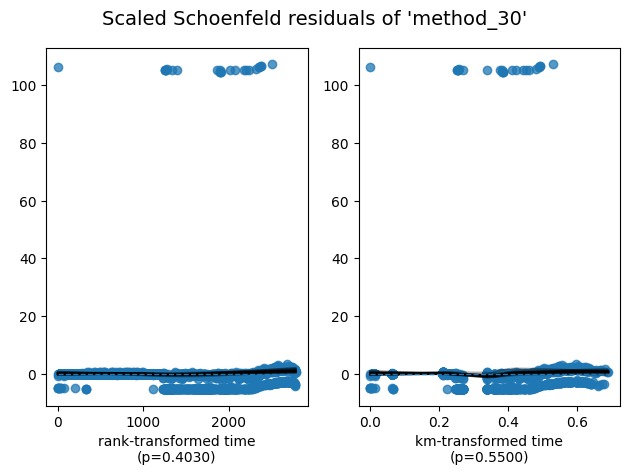

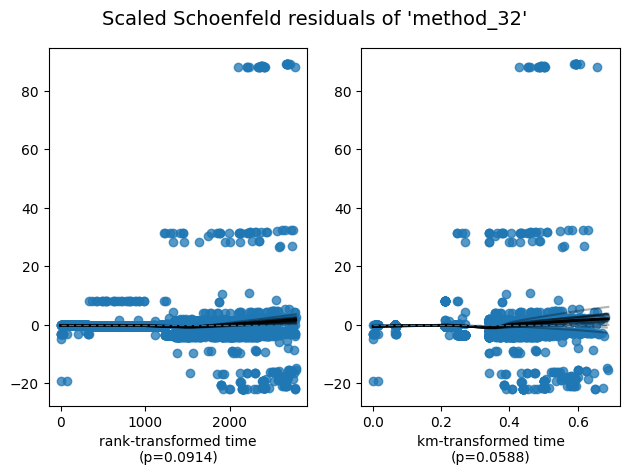

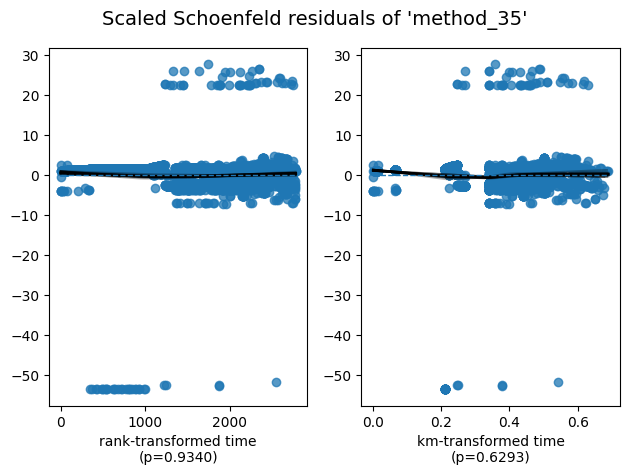

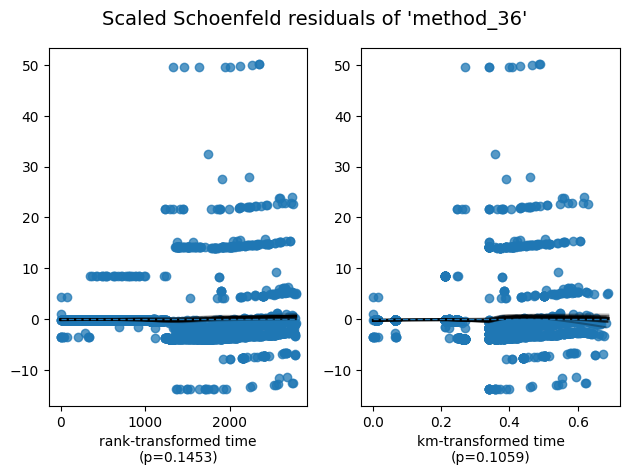

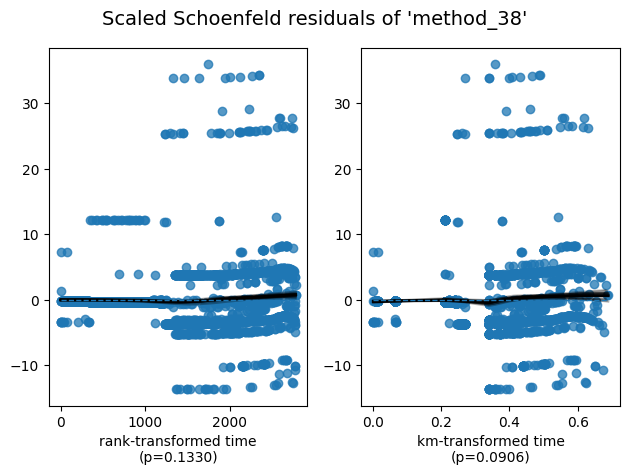

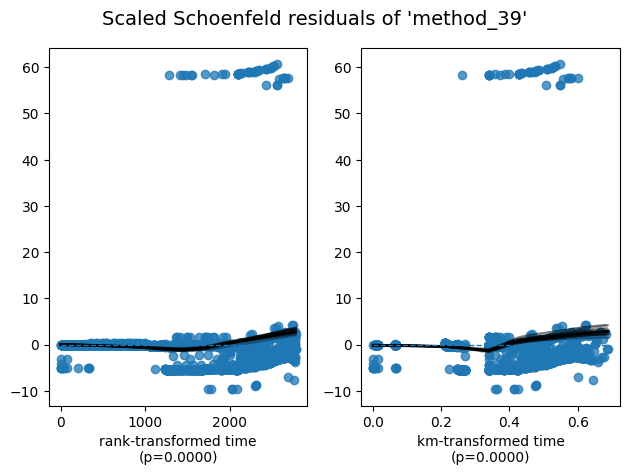

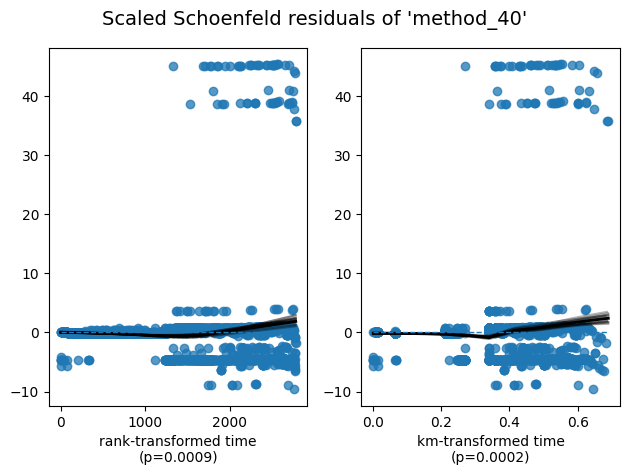

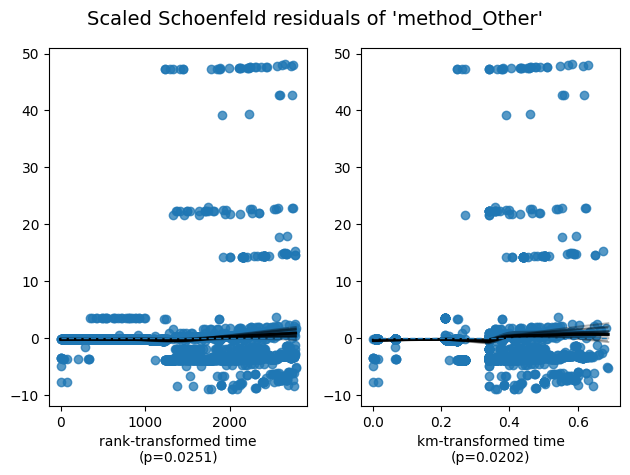

In [18]:
cox_sample_adjusted = df_adjusted.sample(n=5000, random_state=42)

cph_sample_adj = CoxPHFitter(penalizer=0.01)
cph_sample_adj.fit(cox_sample_adjusted, duration_col='duration_days', event_col='event')

cph_sample_adj.check_assumptions(
    cox_sample_adjusted,
    p_value_threshold=0.05,
    show_plots=True
)

#### n = 10000

test_statistic             p   -log2(p)
is_auto_renew  km          0.129920  7.185154e-01   0.476909
               rank        0.248489  6.181411e-01   0.693992
method_29      km          5.614814  1.780927e-02   5.811228
               rank        4.164415  4.128167e-02   4.598355
method_30      km          0.966985  3.254332e-01   1.619567
               rank        1.980707  1.593159e-01   2.650037
method_32      km         12.242676  4.670880e-04  11.064018
               rank        8.255453  4.062976e-03   7.943248
method_35      km          0.153569  6.951479e-01   0.524608
               rank        0.320002  5.716062e-01   0.806906
method_36      km          5.510267  1.890517e-02   5.725076
               rank        4.432000  3.527116e-02   4.825367
method_38      km          6.763332  9.304985e-03   6.747780
               rank        5.072426  2.430934e-02   5.362346
method_39      km         38.707184  4.923933e-10  30.919470
               rank       35.046967  3.218479e-09  28.210974
method_40      km         25.122225  5.380912e-07  20.825646
               rank       20.994494  4.606052e-06  17.728038
method_Other   km         10.065419  1.510782e-03   9.370489
               rank        9.308888  2.280449e-03   8.776467
plan_0 days    km          0.001384  9.703230e-01   0.043463
               rank        0.013078  9.089528e-01   0.137723
plan_1–7 days  km         53.702823  2.332279e-13  41.963325
               rank       71.431358  2.870733e-17  54.951358
plan_8–29 days km         12.940648  3.215238e-04  11.602787
               rank        3.546402  5.967471e-02   4.066737
plan_>30 days  km         17.826162  2.420324e-05  15.334440
               rank       11.203486  8.164380e-04  10.258369


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.6181)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7185)'>]]

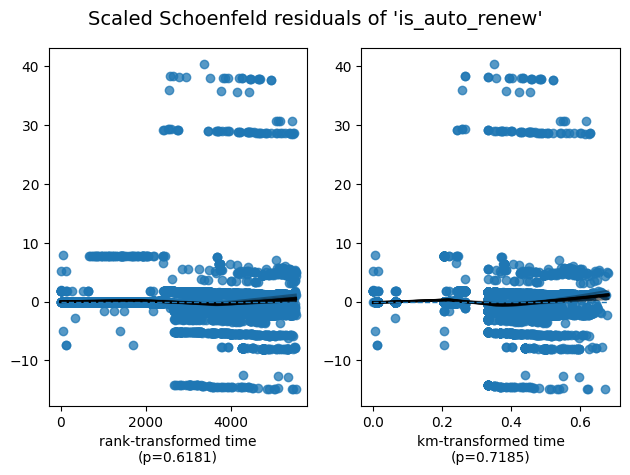

In [29]:
# 10000 sample diagnostics for Model 1
cox_sample_adjusted = df_adjusted.sample(n=10000, random_state=42)

cph_sample_adj = CoxPHFitter(penalizer=0.01)
cph_sample_adj.fit(cox_sample_adjusted, duration_col='duration_days', event_col='event')

# Run the mathematical test for all covariates
results_adj = proportional_hazard_test(cph_sample_adj, cox_sample_adjusted, time_transform=['km', 'rank'])
display(results_adj.summary)

# Only plot the Schoenfeld residuals for auto renew
cph_sample_adj.check_assumptions(
    cox_sample_adjusted,
    p_value_threshold=0.05,
    show_plots=True,
    columns=['is_auto_renew']
)



test_statistic             p   -log2(p)
is_auto_renew  km          0.980527  3.220688e-01   1.634559
               rank        1.189119  2.755073e-01   1.859838
method_29      km          5.742660  1.655770e-02   5.916354
               rank        4.200418  4.041401e-02   4.629001
method_30      km          1.406916  2.355690e-01   2.085779
               rank        2.916573  8.767391e-02   3.511709
method_32      km         17.087493  3.569661e-05  14.773854
               rank       11.887033  5.652609e-04  10.788795
method_35      km          0.602349  4.376832e-01   1.192041
               rank        1.061988  3.027622e-01   1.723743
method_36      km          6.074595  1.371398e-02   6.188209
               rank        5.099910  2.392708e-02   5.385212
method_38      km          8.043294  4.567241e-03   7.774461
               rank        5.756735  1.642556e-02   5.927913
method_39      km         52.773613  3.742962e-13  41.280885
               rank       46.636016  8.547479e-12  36.767638
method_40      km         29.206506  6.506039e-08  23.873645
               rank       25.809930  3.767452e-07  21.339907
method_Other   km         12.081565  5.092282e-04  10.939400
               rank       11.752596  6.075843e-04  10.684628
plan_0 days    km          0.307461  5.792422e-01   0.787762
               rank        0.169058  6.809506e-01   0.554378
plan_1–7 days  km         94.225750  2.815146e-22  71.589208
               rank      123.666982  9.963819e-29  93.019216
plan_8–29 days km         19.734522  8.897941e-06  16.778097
               rank        5.289188  2.145822e-02   5.542326
plan_>30 days  km         24.022037  9.523937e-07  20.001939
               rank       14.982812  1.084949e-04  13.170085


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.2755)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3221)'>]]

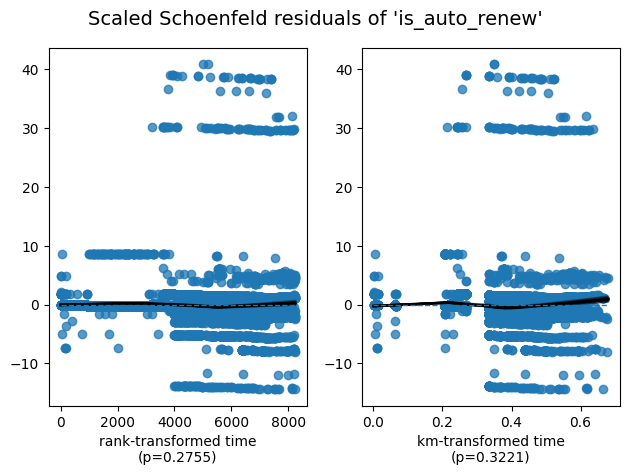

In [30]:
# 15000 sample diagnostics for Model 1
cox_sample_adjusted = df_adjusted.sample(n=15000, random_state=42)

cph_sample_adj = CoxPHFitter(penalizer=0.01)
cph_sample_adj.fit(cox_sample_adjusted, duration_col='duration_days', event_col='event')

# Run the mathematical test for ALL covariates 
results_adj = proportional_hazard_test(cph_sample_adj, cox_sample_adjusted, time_transform=['km', 'rank'])
display(results_adj.summary)

# Only plot the Schoenfeld residuals for auto renew
cph_sample_adj.check_assumptions(
    cox_sample_adjusted,
    p_value_threshold=0.05,
    show_plots=True,
    columns=['is_auto_renew']
)



- With the 5,000-user sample, `is_auto_renew` passes the proportional hazards test (p = 0.83). The non-monthly plan durations (`1–7 days`, `8–29 days`, and `>30 days`) fail, as do methods 39 and 40. Since the PH test only indicates whether an effect stays constant over time, this suggests these hazard ratios should be read as time-averages rather than constant.

- Doubling the sample to 10,000 users, `is_auto_renew`'s p-value shifts (p = 0.71) but remains a pass and consistent with the 5,000-sample result, its hazard ratio continues to hold up as a reasonable constant summary across follow-up time at this sample size. The plan duration failures persist, with p-values shrinking further (e.g., `plan_1–7 days` drops to p = 2.33e-13). `method_32` also begins showing a significant deviation at this sample size.

- At 15,000 users, `is_auto_renew` continues to pass (p = 0.32), reinforcing the pattern across all three sample sizes. The plan duration violations continue to grow(`plan_1–7 days` reaches p = 2.81e-22), and several additional payment methods (including 29, 30, 32, 36, and 38) now show statistically significant deviations. However, unlike plan duration and methods 39/40 which fail consistently across every sample size and both time transforms, these did not fail consistently across all three runs, which might indicate the effect og test power with increasing sample size rather than meaningful violations. Methods 39 and 40 remain the most consistent violations alongside plan duration.

### 2.3 The Stratified Adjusted Multivariable Model: Model 2

Plan duration showed the strongest and most consistent PH violation across every sample size tested, and this is practically expected because different plan lengths create different renewal trendss (a 30-day plan creates roughly twelve renewals yearly, a 365-day/410-day plan creates one), so there is no reason to expect its relative effect on churn risk to stay constant. Stratifying (`strata=['plan_group']`) removes it from the hazard ratio table but lets the other variables be estimated within each plan group.

Model 2: Stratified by Plan Duration


model,lifelines.CoxPHFitter
duration col,'duration_days'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,plan_group
baseline estimation,breslow
number of observations,917697
number of events observed,508252
partial log-likelihood,-6023516.82
time fit was run,2026-09-23 23:12:58 UTC


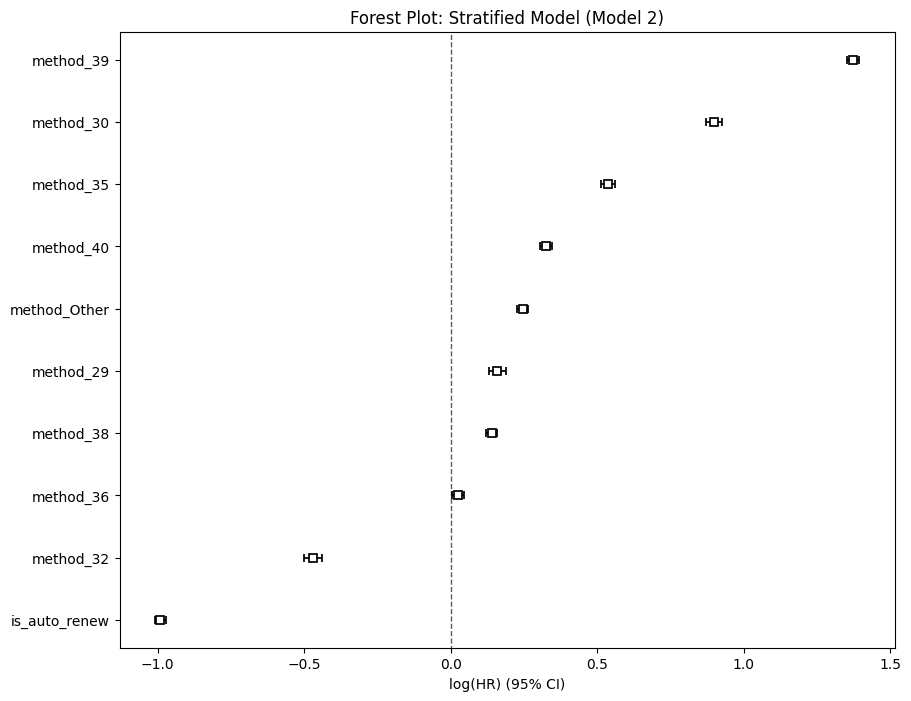

In [21]:
# Drop plan_dummies and replace with the plan_group column.
df_stratified = pd.concat([
    cox_data_unadj[['duration_days', 'event', 'is_auto_renew', 'plan_group']], 
    method_dummies
], axis=1)

# Fit Model 2 
cph_stratified = CoxPHFitter(penalizer=0.01)
cph_stratified.fit(
    df_stratified, 
    duration_col='duration_days', 
    event_col='event',
    strata=['plan_group']
)

print("Model 2: Stratified by Plan Duration")
cph_stratified.print_summary()

# Forest Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
cph_stratified.plot()
plt.title('Forest Plot: Stratified Model (Model 2)')
plt.show()

- The risk multiplier for `is_auto_renew` (HR = 0.37, CI:0.36–0.38) didn't change at all. Stratifying plan duration didn't meaningfully change auto-renew's effect, suggesting that the 63% risk reduction provided by auto-renewal is immune to plan duration. Whether a user is on a 7-day pass or a 410-day contract, enabling auto-renew is the single most effective thing they can do to survive.

- Payment Method 35 has the most notable change, falling to 1.71x, it suggests what looked like method_35's independent risk in the unstratified model was actually mixed up (for example, method 35 might be heavily influenced by short-term plans). On the other hand, method 39 churn risk actually increases in the stratified model to 3.95x. This means that if you take two users on the exact same plan length, on Method 39 is nearly 4 times more likely to churn at any given moment. On the flip side, method_32 maintains a similar protective effect (HR = 0.62).

- Concordance now falls significantly to 0.61. Stratifying removes plan duration's contribution to predicting risk so this drop is expected, but it means the stratified Model 2 is worse at discriminating who churns sooner than Model 1, even though its remaining hazard ratios are  more trustworthy over time.

### Proportional Hazards Assumptions Check: Model 2

#### n = 5000


   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'method_39' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['method_39', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


2. Variable 'method_40' failed the non-proportional test: p-value is 0.0002.

   Advice: with so few unique values (only 2), you can include `strata=['method_40', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


3. Variable 'method_Other' failed the non-proportional test: p-value is 0.0189.

   Advice: with so few unique values (only 2), you can include `strata=['method_Other', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20haz

[[<Axes: xlabel='rank-transformed time\n(p=0.2213)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7364)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7518)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1968)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2540)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5976)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0935)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0777)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5031)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5280)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9910)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1722)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8706)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1145)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0001)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0004)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0002)'>],
 [<Axes: xlabel='rank-transformed tim

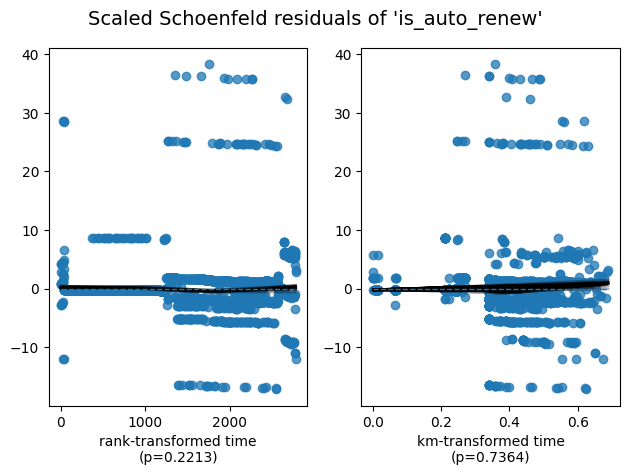

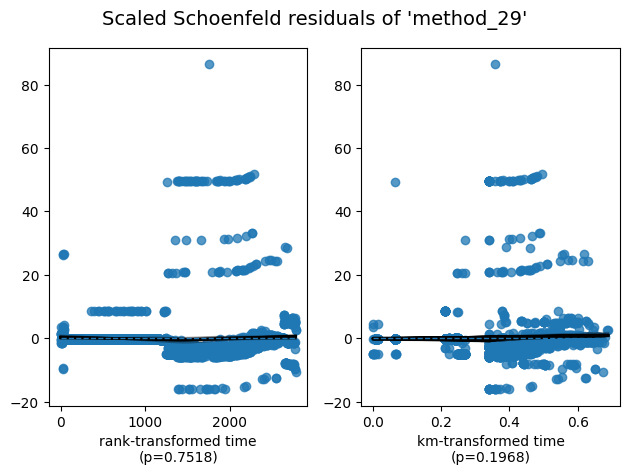

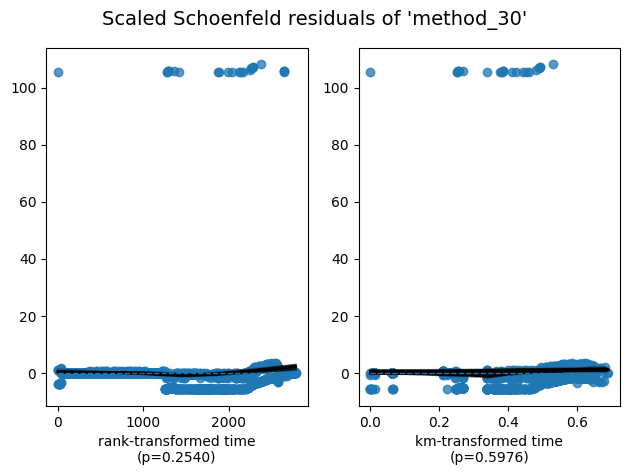

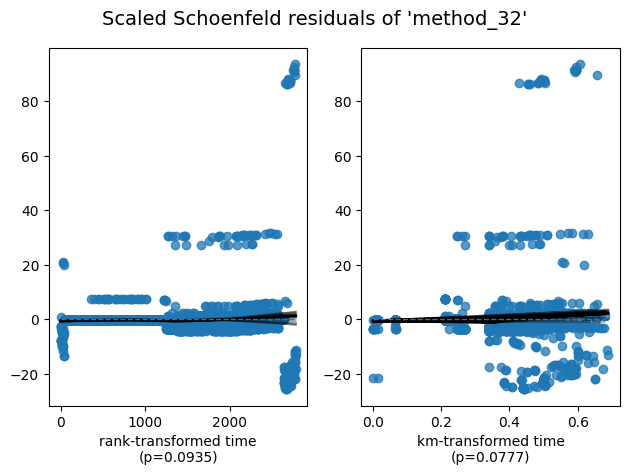

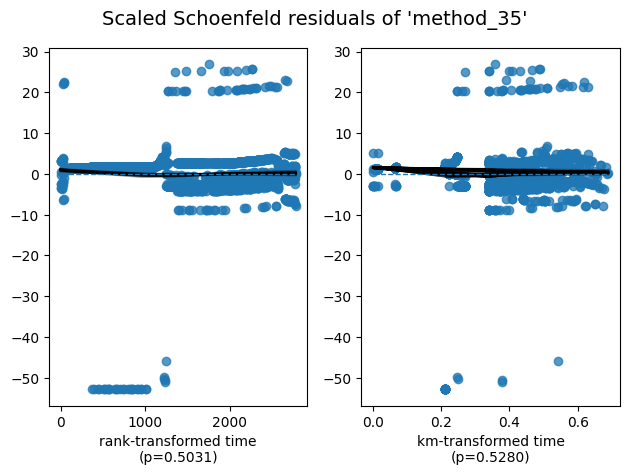

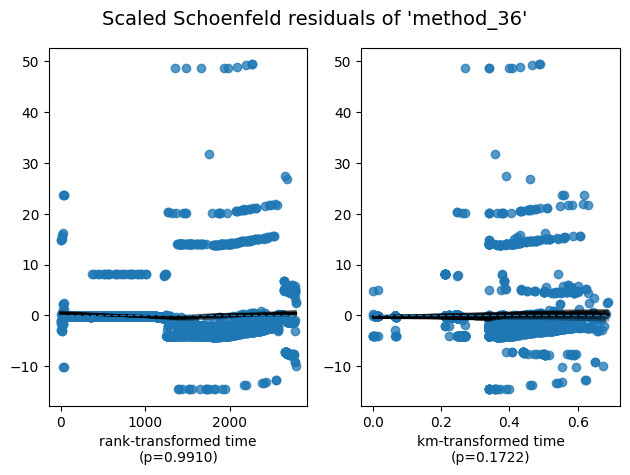

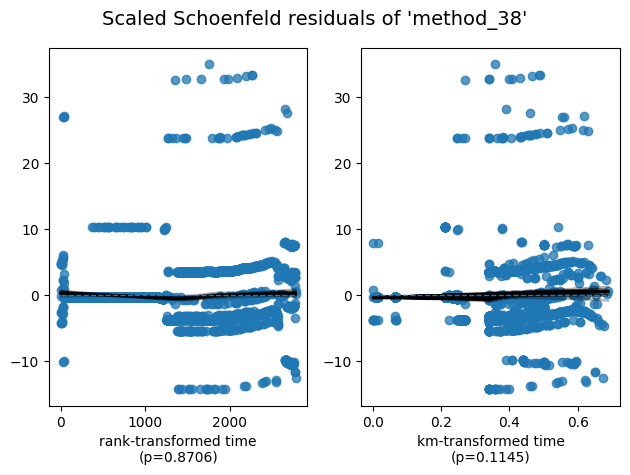

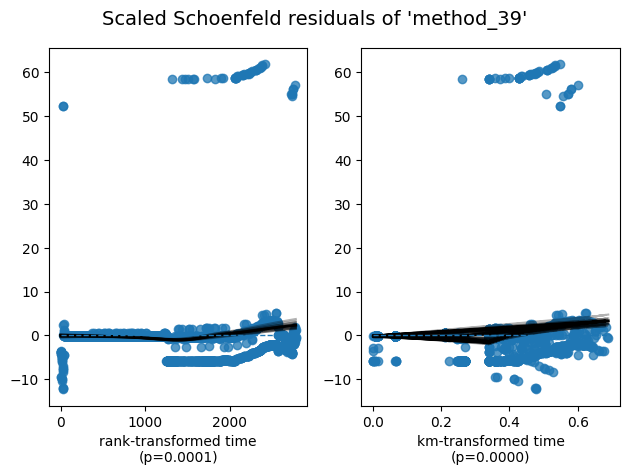

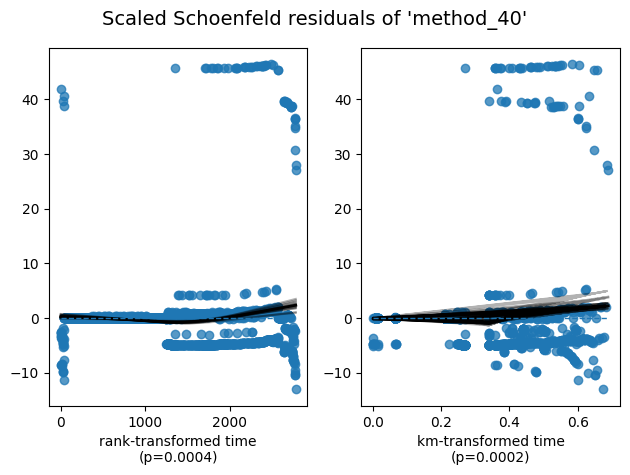

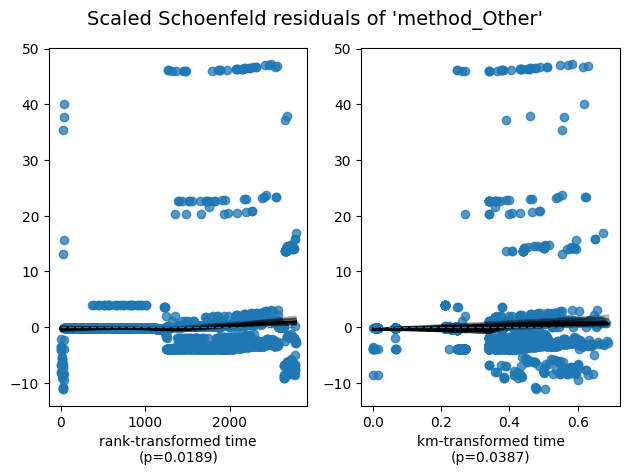

In [22]:
cox_sample_stratified = df_stratified.sample(n=5000, random_state=42)

cph_sample_strat = CoxPHFitter(penalizer=0.01)
cph_sample_strat.fit(
    cox_sample_stratified, 
    duration_col='duration_days', 
    event_col='event',
    strata=['plan_group']
)

cph_sample_strat.check_assumptions(
    cox_sample_stratified,
    p_value_threshold=0.05,
    show_plots=True
)

#### n = 10000

test_statistic             p   -log2(p)
is_auto_renew km          0.273167  6.012151e-01   0.734047
              rank        1.049006  3.057361e-01   1.709641
method_29     km          3.906280  4.810597e-02   4.377640
              rank        0.918388  3.378985e-01   1.565338
method_30     km          0.494929  4.817368e-01   1.053683
              rank        5.615161  1.780574e-02   5.811513
method_32     km         11.827200  5.837170e-04  10.742443
              rank        8.090523  4.449731e-03   7.812066
method_35     km          0.031334  8.594984e-01   0.218433
              rank        0.378772  5.382612e-01   0.893622
method_36     km          3.670133  5.539575e-02   4.174081
              rank        0.541486  4.618177e-01   1.114605
method_38     km          5.752076  1.646918e-02   5.924088
              rank        0.850818  3.563210e-01   1.488751
method_39     km         36.213389  1.768513e-09  29.074816
              rank       24.528294  7.322662e-07  20.381128
method_40     km         24.131649  8.996943e-07  20.084062
              rank       30.504357  3.331175e-08  24.839394
method_Other  km          8.771680  3.059435e-03   8.352519
              rank       11.444151  7.171939e-04  10.445349


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.3057)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6012)'>]]

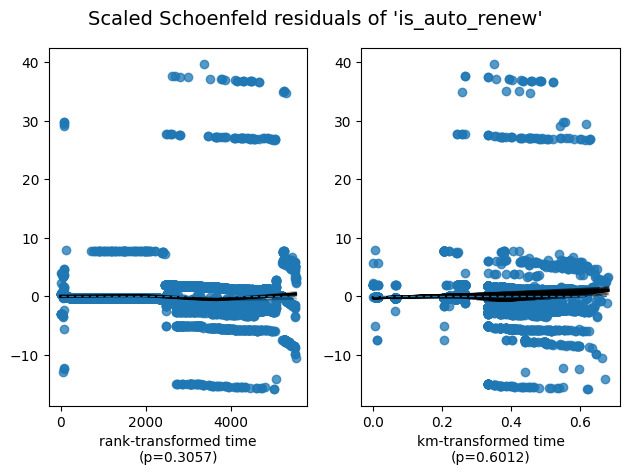

In [31]:
# 10000 sample diagnostics for Model 2 
cox_sample_stratified = df_stratified.sample(n=10000, random_state=42)

cph_sample_strat = CoxPHFitter(penalizer=0.01)
cph_sample_strat.fit(
    cox_sample_stratified, 
    duration_col='duration_days', 
    event_col='event',
    strata=['plan_group']
)

# Run the test for all covariates
results_strat = proportional_hazard_test(cph_sample_strat, cox_sample_stratified, time_transform=['km', 'rank'])
display(results_strat.summary)

# Only plot the Schoenfeld residuals for Auto-Renew
cph_sample_strat.check_assumptions(
    cox_sample_stratified,
    p_value_threshold=0.05,
    show_plots=True,
    columns=['is_auto_renew']
)


#### n = 15000 sample

test_statistic             p   -log2(p)
is_auto_renew km          1.401154  2.365304e-01   2.079903
              rank        2.759806  9.665997e-02   3.370938
method_29     km          3.815837  5.077025e-02   4.299873
              rank        0.610393  4.346397e-01   1.202108
method_30     km          0.666731  4.141935e-01   1.271623
              rank        7.567186  5.944052e-03   7.394338
method_32     km         16.088447  6.045169e-05  14.013858
              rank        9.131986  2.511790e-03   8.637069
method_35     km          0.034275  8.531238e-01   0.229173
              rank        0.485240  4.860582e-01   1.040799
method_36     km          3.898473  4.833001e-02   4.370937
              rank        0.592358  4.415086e-01   1.179487
method_38     km          7.296834  6.907620e-03   7.177595
              rank        1.010265  3.148393e-01   1.667312
method_39     km         49.855598  1.654875e-12  39.136415
              rank       30.454449  3.417986e-08  24.802278
method_40     km         27.738207  1.388923e-07  22.779530
              rank       33.567888  6.881956e-09  27.114534
method_Other  km          9.734851  1.808067e-03   9.111336
              rank       11.887371  5.651584e-04  10.789057


   Bootstrapping lowess lines. May take a moment...



Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.0967)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2365)'>]]

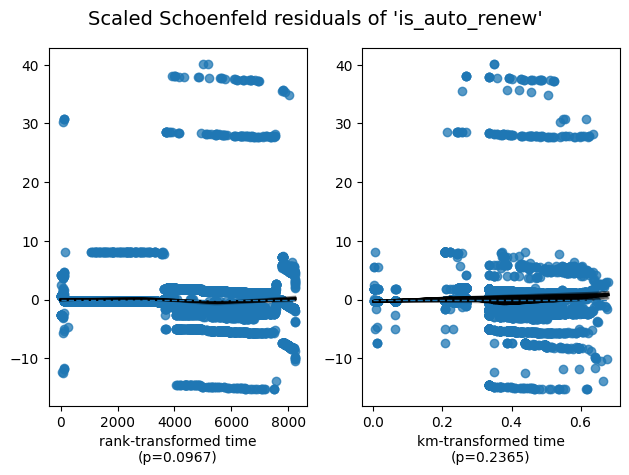

In [33]:
# 15000 sample diagnostics for Model 2
cox_sample_stratified = df_stratified.sample(n=15000, random_state=42)

cph_sample_strat = CoxPHFitter(penalizer=0.01)
cph_sample_strat.fit(
    cox_sample_stratified, 
    duration_col='duration_days', 
    event_col='event',
    strata=['plan_group']
)

# Run the test for all covariates
from lifelines.statistics import proportional_hazard_test
results_strat = proportional_hazard_test(cph_sample_strat, cox_sample_stratified, time_transform=['km', 'rank'])
display(results_strat.summary)

# Only plot the Schoenfeld residuals for Auto-Renew
cph_sample_strat.check_assumptions(
    cox_sample_stratified,
    p_value_threshold=0.05,
    show_plots=True,
    columns=['is_auto_renew']
)



- With the 5,000 sample, `is_auto_renew` passes the test (p = 0.74), consistent with earlier samples its hazard ratio continues to hold up as a reasonable constant estimate. Most payment methods, including method_32 and method_35, also pass. Passing indicates their hazard ratios can be treated as stable over the follow-up period but it says nothing about how large or small those hazard ratios themselves are, or whether the method is risky in an total sense. The only failures at this sample size are methods 39, 40, and Other which is consistent with methods 39 and 40's pattern from the unstratified model.

- Doubling the sample does not change `is_auto_renew`'s result (p = 0.60), nor does tripling it (p = 0.23). This pass once again holds consistently across all three sample sizes, marking a genuinely stable estimate rather than a fluke of one particular sample. At 15,000 users, some additional payment methods show significant deviations.